# Evaluation — HARNN Word2Vec + Global

Giữ lại các đánh giá cơ bản cho phân loại đa lớp.

| Cell | Nội dung |
|------|----------|
| 1 | Load model + test set + dự đoán |
| 2 | Ma trận nhầm lẫn (Confusion Matrix) L1 |
| 3 | Accuracy, Precision, Recall, F1 (Macro/Micro) |


## Cell 1 — Load model & test set


In [31]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    )
from torch.utils.data import DataLoader, Dataset

DATA_DIR = Path(r'C:\Users\Admin\Documents\nlp\NLP_Project\data\process_data')
SPLIT_DATA_DIR = Path(r'C:\Users\Admin\Documents\nlp\NLP_Project\data')
OUTPUT_DIR = Path(r'C:\Users\Admin\Documents\nlp\NLP_Project\output')
CKPT_PATH = OUTPUT_DIR / 'models' / 'checkpoints' / 'best_model.pt'
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

MAX_LEN, BATCH_SIZE, EMBED_DIM, HIDDEN = 512, 64, 100, 256
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with open(SPLIT_DATA_DIR / 'test_data.json', encoding='utf-8') as f:
    test_articles = json.load(f)
with open(DATA_DIR / 'vocab.json', encoding='utf-8') as f:
    vocab = json.load(f)
with open(DATA_DIR / 'label_map.json', encoding='utf-8') as f:
    label_map = json.load(f)

VOCAB_SIZE = len(vocab)
NUM_CLASSES = [len(label_map['l1']), len(label_map['l2']), len(label_map['l3'])]
IDX2LABEL = {lv: {v: k for k, v in label_map[lv].items()} for lv in ['l1', 'l2', 'l3']}

class VnExpressDataset(Dataset):
    def __init__(self, articles, vocab, max_len=MAX_LEN):
        self.articles, self.vocab, self.max_len = articles, vocab, max_len

    def __len__(self):
        return len(self.articles)

    def __getitem__(self, idx):
        item = self.articles[idx]
        ids = [self.vocab.get(t, 1) for t in item['tokens']][: self.max_len]
        ids += [0] * (self.max_len - len(ids))
        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(item['vec_l1'], dtype=torch.float),
            torch.tensor(item['vec_l2'], dtype=torch.float),
            torch.tensor(item['vec_l3'], dtype=torch.float),
        )

test_set = VnExpressDataset(test_articles, vocab)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Test set (from test_data.json): {len(test_set)} bài')

class HARNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes_per_level, dropout=0.5):
        super().__init__()
        self.num_levels = len(num_classes_per_level)
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.bigru = nn.GRU(embed_dim, hidden_size, bidirectional=True, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.attention = nn.ModuleList([nn.Linear(hidden_size * 2, 1) for _ in range(self.num_levels)])
        self.ham = nn.LSTMCell(hidden_size * 2, hidden_size)
        self.classifiers = nn.ModuleList([nn.Linear(hidden_size * 3, n) for n in num_classes_per_level])

    def forward(self, x):
        batch_size = x.size(0)
        doc, _ = self.bigru(self.dropout(self.embedding(x)))
        doc = self.dropout(doc)
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c = torch.zeros(batch_size, self.hidden_size, device=x.device)
        preds = []
        for lv in range(self.num_levels):
            context = (torch.softmax(self.attention[lv](doc), dim=1) * doc).sum(dim=1)
            h, c = self.ham(context, (h, c))
            feat = self.dropout(torch.cat([context, h], dim=-1))
            preds.append(torch.sigmoid(self.classifiers[lv](feat)))
        return preds

model = HARNN(VOCAB_SIZE, EMBED_DIM, HIDDEN, NUM_CLASSES).to(device)
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Checkpoint: epoch {ckpt['epoch']}  val F1-L1={ckpt['val_f1_l1']:.3f}")

@torch.no_grad()
def get_preds_labels():
    probs_per_level = [[] for _ in range(3)]
    labels_per_level = [[] for _ in range(3)]
    for ids, l1, l2, l3 in test_loader:
        out = model(ids.to(device))
        for i, lbl in enumerate([l1, l2, l3]):
            probs_per_level[i].append(out[i].cpu().numpy())
            labels_per_level[i].append(lbl.numpy())
    probs = [np.concatenate(x) for x in probs_per_level]
    labels = [np.concatenate(x) for x in labels_per_level]
    return probs, labels

probs, labels = get_preds_labels()
true_class = [np.argmax(labels[i], axis=1) for i in range(3)]
pred_class = [np.argmax(probs[i], axis=1) for i in range(3)]

l3_valid_mask = labels[2].sum(axis=1) > 0
true_l3_valid = true_class[2][l3_valid_mask]
pred_l3_valid = pred_class[2][l3_valid_mask]

l3_to_l2 = {}
true_l2_all = true_class[1]
for l3_idx in range(NUM_CLASSES[2]):
    idx = np.where(labels[2][:, l3_idx] > 0)[0]
    if len(idx):
        l3_to_l2[l3_idx] = int(np.bincount(true_l2_all[idx], minlength=NUM_CLASSES[1]).argmax())

print(f'Predictions collected: {len(true_class[0])} bài')
print(f'L3 valid samples: {l3_valid_mask.sum()} / {len(l3_valid_mask)} bài')
print(f'L3->L2 map inferred for {len(l3_to_l2)} / {NUM_CLASSES[2]} nhãn L3')

Test set (from test_data.json): 1182 bài
Checkpoint: epoch 15  val F1-L1=0.887
Predictions collected: 1182 bài
L3 valid samples: 264 / 1182 bài
L3->L2 map inferred for 22 / 33 nhãn L3


## Cell 2 — Confusion Matrix L1
Thấy domain nào hay bị nhầm sang domain nào.


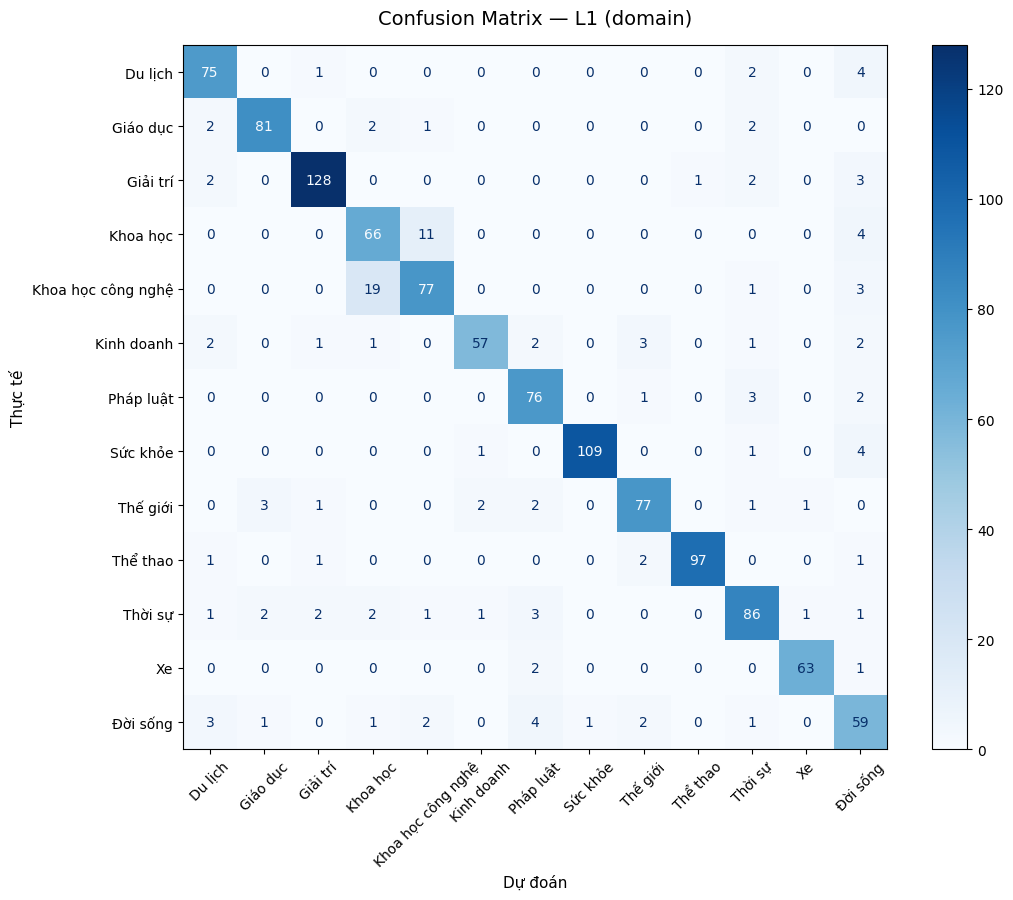


Top nhầm lẫn L1:
  Khoa học công nghệ → Khoa học         19 bài
  Khoa học        → Khoa học công nghệ  11 bài
  Đời sống        → Pháp luật        4 bài
  Sức khỏe        → Đời sống         4 bài
  Khoa học        → Đời sống         4 bài
  Du lịch         → Đời sống         4 bài
  Đời sống        → Du lịch          3 bài
  Thời sự         → Pháp luật        3 bài


In [32]:
# Confusion Matrix cho L1 (tối giản)
true_l1 = true_class[0]
pred_l1 = pred_class[0]

label_names = [IDX2LABEL['l1'][i] for i in range(NUM_CLASSES[0])]
cm = confusion_matrix(true_l1, pred_l1)

fig, ax = plt.subplots(figsize=(11, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)

ax.set_title('Confusion Matrix — L1 (domain)', fontsize=14, pad=15)
ax.set_xlabel('Dự đoán', fontsize=11)
ax.set_ylabel('Thực tế', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrix_l1.png', dpi=150)
plt.show()

# Top cặp nhầm lẫn
print('\nTop nhầm lẫn L1:')
errors = [
    (cm[i, j], label_names[i], label_names[j])
    for i in range(len(label_names))
    for j in range(len(label_names))
    if i != j and cm[i, j] > 0
]
for cnt, true, pred in sorted(errors, reverse=True)[:8]:
    print(f'  {true:<15} → {pred:<15}  {cnt} bài')

## Cell 3 — Accuracy, Precision, Recall, F1 (Macro/Micro)


EVALUATION (L3 chỉ tính trên mẫu có nhãn L3 thật):
--------------------------------------------------------------------------------
Level       Accuracy   P_micro   R_micro  F1_micro   P_macro   R_macro  F1_macro
--------------------------------------------------------------------------------
L1             0.889     0.889     0.889     0.889     0.887     0.885     0.885
L2             0.629     0.629     0.629     0.629     0.563     0.620     0.568
L3(valid)      0.807     0.807     0.807     0.807     0.732     0.737     0.707
--------------------------------------------------------------------------------

HIERARCHY DIAGNOSTICS (L3):
- Parent consistency: 0.818
- Strict hierarchical accuracy: 0.735

SỐ LƯỢNG BÀI TEST THEO TỪNG MỨC:
L1: 1182 bài test
L2: 1182 bài test
L3: 264 bài test


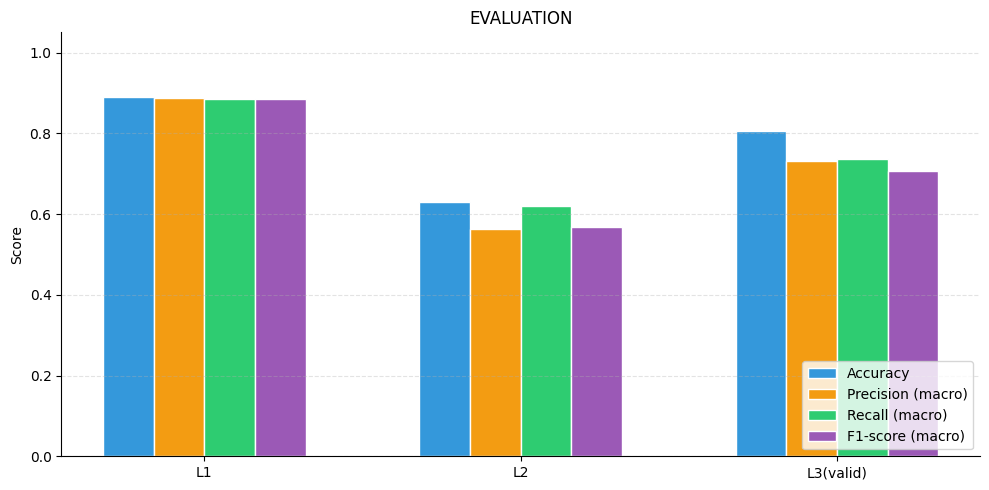

In [33]:
levels = ['L1', 'L2', 'L3(valid)']
eval_sets = [
    ('L1', true_class[0], pred_class[0]),
    ('L2', true_class[1], pred_class[1]),
    ('L3(valid)', true_l3_valid, pred_l3_valid),
]

def calc_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision_micro': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'Recall_micro': recall_score(y_true, y_pred, average='micro', zero_division=0),
        'F1_micro': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'Precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

metrics_rows = []
for lv, y_true, y_pred in eval_sets:
    row = {'Level': lv}
    row.update(calc_metrics(y_true, y_pred))
    metrics_rows.append(row)

print('EVALUATION (L3 chỉ tính trên mẫu có nhãn L3 thật):')
header = f"{'Level':<10} {'Accuracy':>9} {'P_micro':>9} {'R_micro':>9} {'F1_micro':>9} {'P_macro':>9} {'R_macro':>9} {'F1_macro':>9}"
print('-' * len(header))
print(header)
print('-' * len(header))
for r in metrics_rows:
    print(
        f"{r['Level']:<10} {r['Accuracy']:>9.3f} {r['Precision_micro']:>9.3f} {r['Recall_micro']:>9.3f} "
        f"{r['F1_micro']:>9.3f} {r['Precision_macro']:>9.3f} {r['Recall_macro']:>9.3f} {r['F1_macro']:>9.3f}"
    )
print('-' * len(header))

pred_l2_valid = pred_class[1][l3_valid_mask]
true_l2_valid = true_class[1][l3_valid_mask]
pred_l3_parent = np.array([l3_to_l2.get(int(c), -1) for c in pred_l3_valid])
hier_parent_consistency = (pred_l3_parent == pred_l2_valid).mean()
hier_strict_acc = ((pred_l3_valid == true_l3_valid) & (pred_l2_valid == true_l2_valid)).mean()

print('\nHIERARCHY DIAGNOSTICS (L3):')
print(f'- Parent consistency: {hier_parent_consistency:.3f}')
print(f'- Strict hierarchical accuracy: {hier_strict_acc:.3f}')

print('\nSỐ LƯỢNG BÀI TEST THEO TỪNG MỨC:')
print(f'L1: {len(true_class[0])} bài test')
print(f'L2: {len(true_class[1])} bài test')
print(f'L3: {len(true_l3_valid)} bài test')

x = np.arange(len(levels))
width = 0.16
acc = [r['Accuracy'] for r in metrics_rows]
pre = [r['Precision_macro'] for r in metrics_rows]
rec = [r['Recall_macro'] for r in metrics_rows]
f1m = [r['F1_macro'] for r in metrics_rows]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 1.5 * width, acc, width, label='Accuracy', color='#3498db', edgecolor='white', linewidth=1)
ax.bar(x - 0.5 * width, pre, width, label='Precision (macro)', color='#f39c12', edgecolor='white', linewidth=1)
ax.bar(x + 0.5 * width, rec, width, label='Recall (macro)', color='#2ecc71', edgecolor='white', linewidth=1)
ax.bar(x + 1.5 * width, f1m, width, label='F1-score (macro)', color='#9b59b6', edgecolor='white', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(levels)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('EVALUATION')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'basic_metrics_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()